Importing Required Dependencies

In [125]:
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
from sklearn.model_selection import train_test_split
from sklearn import svm
from sklearn.metrics import accuracy_score

In [126]:
print("numpy", np.__version__)
print("pandas", pd.__version__)
print("seaborn", sns.__version__)
print("sklearn", sklearn.__version__)

numpy 2.0.2
pandas 2.2.2
seaborn 0.13.2
sklearn 1.6.1


Data Collection & Processing

In [127]:
loan_dataset = pd.read_csv('/content/drive/MyDrive/Loan_status_model_files/loan_data.csv')
type(loan_dataset)

pandas.core.frame.DataFrame

In [128]:
print(loan_dataset['Loan_Status'].value_counts())

Loan_Status
Y    422
N    192
Name: count, dtype: int64


In [129]:
loan_dataset.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [130]:
loan_dataset.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [131]:
#Counting the missing values in each columns
loan_dataset.isnull().sum()

,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


In [132]:
#Dropping the missing values (As Several Columns are categorical)
loan_dataset = loan_dataset.dropna()

In [133]:
#Checking Size of Remaining data post dropping NA
loan_dataset.shape

(480, 13)

In [134]:
#Counting the missing values in each columns
loan_dataset.isnull().sum()

,0
Loan_ID,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0


In [135]:
# Label encoding
loan_dataset.replace({'Loan_Status': {'N':0,'Y':1}}, inplace=True)

/tmp/ipython-input-135-2915803514.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  loan_dataset.replace({'Loan_Status': {'N':0,'Y':1}}, inplace=True)
/tmp/ipython-input-135-2915803514.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  loan_dataset.replace({'Loan_Status': {'N':0,'Y':1}}, inplace=True)


In [136]:
loan_dataset.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,0
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,1
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,1
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,1
5,LP001011,Male,Yes,2,Graduate,Yes,5417,4196.0,267.0,360.0,1.0,Urban,1


In [137]:
#Dependent Column Values
loan_dataset['Dependents'].value_counts()

,count
Dependents,
0,274
2,85
1,80
3+,41


In [138]:
#Replacing All 3+ values in Dependents with numerical value in order to give me as input in model
loan_dataset = loan_dataset.replace(to_replace='3+', value=4)

In [139]:
#Dependent Column Values
loan_dataset['Dependents'].value_counts()

,count
Dependents,
0,274
2,85
1,80
4,41


Data Visualization

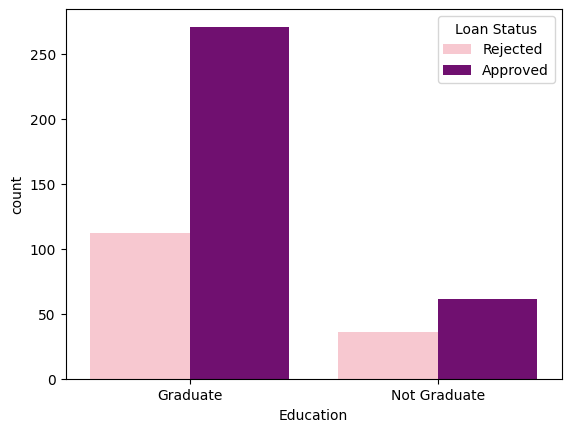

In [140]:
#Education vs Loan Status
ST_1 = sns.countplot(x='Education', hue='Loan_Status', data=loan_dataset, palette=['pink', 'purple'])
ST_1.legend(title='Loan Status', labels=['Rejected', 'Approved'])

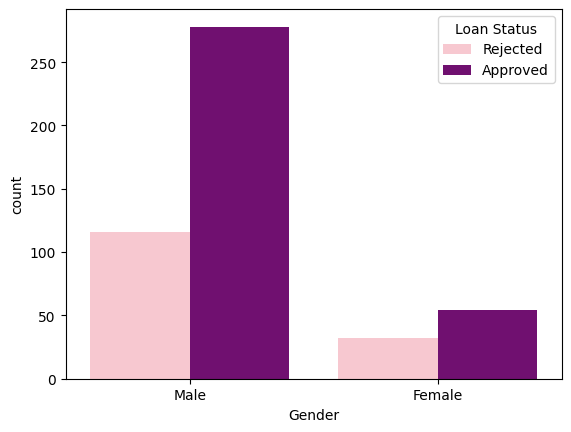

In [141]:
#Gender vs Loan Amount
ST_3 = sns.countplot(x='Gender', hue='Loan_Status', data=loan_dataset,palette=['pink', 'purple'])
ST_3.legend(title='Loan Status', labels=['Rejected', 'Approved'])

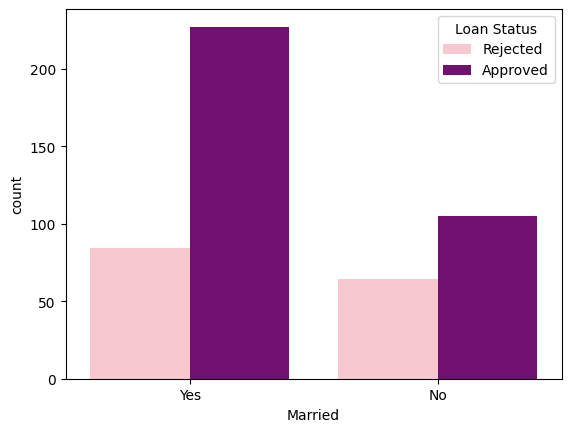

In [142]:
#Marital Status vs Loan Amount
ST_2 = sns.countplot(x='Married', hue='Loan_Status', data=loan_dataset,palette=['pink', 'purple'])
ST_2.legend(title='Loan Status', labels=['Rejected', 'Approved'])

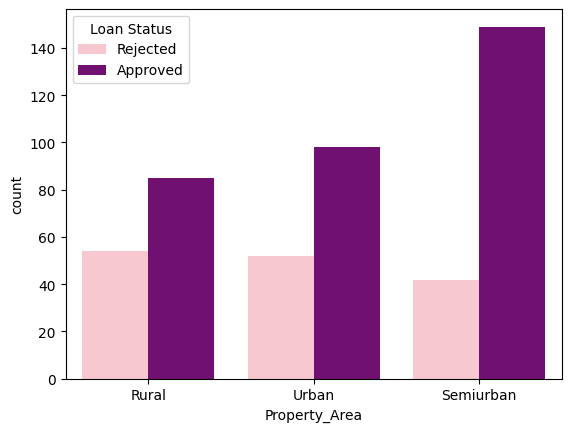

In [143]:
#Property Area vs Loan Amount
ST_3 = sns.countplot(x='Property_Area', hue='Loan_Status', data=loan_dataset,palette=['pink', 'purple'])
ST_3.legend(title='Loan Status', labels=['Rejected', 'Approved'])

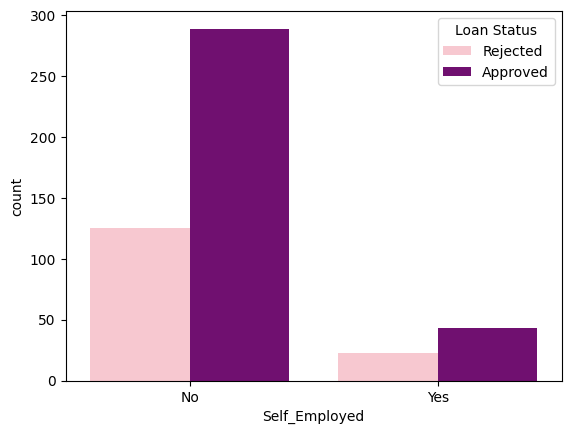

In [144]:
#Self_Employed vs Loan Amount
ST_3 = sns.countplot(x='Self_Employed', hue='Loan_Status', data=loan_dataset,palette=['pink', 'purple'])
ST_3.legend(title='Loan Status', labels=['Rejected', 'Approved'])

In [145]:
#Converting Categorical Columns to Numerical Values
loan_dataset.replace({'Married':{'No':0,'Yes':1},'Gender':{'Male':1,'Female':0}, 'Self_Employed':{'No':0,'Yes':1},
                      'Property_Area':{'Rural':0, 'Semiurban': 1, 'Urban':2}, 'Education':{'Graduate':1, 'Not Graduate':0}},inplace = True)

/tmp/ipython-input-145-3634042463.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  loan_dataset.replace({'Married':{'No':0,'Yes':1},'Gender':{'Male':1,'Female':0}, 'Self_Employed':{'No':0,'Yes':1},


In [146]:
loan_dataset.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
1,LP001003,1,1,1,1,0,4583,1508.0,128.0,360.0,1.0,0,0
2,LP001005,1,1,0,1,1,3000,0.0,66.0,360.0,1.0,2,1
3,LP001006,1,1,0,0,0,2583,2358.0,120.0,360.0,1.0,2,1
4,LP001008,1,0,0,1,0,6000,0.0,141.0,360.0,1.0,2,1
5,LP001011,1,1,2,1,1,5417,4196.0,267.0,360.0,1.0,2,1


In [147]:
# Separating the Data & Label
X = loan_dataset.drop(columns = ['Loan_ID','Loan_Status'], axis=1)
Y = loan_dataset['Loan_Status']

In [148]:
print(X)
print(Y)

     Gender  Married Dependents  Education  Self_Employed  ApplicantIncome  \
1         1        1          1          1              0             4583   
2         1        1          0          1              1             3000   
3         1        1          0          0              0             2583   
4         1        0          0          1              0             6000   
5         1        1          2          1              1             5417   
..      ...      ...        ...        ...            ...              ...   
609       0        0          0          1              0             2900   
610       1        1          4          1              0             4106   
611       1        1          1          1              0             8072   
612       1        1          2          1              0             7583   
613       0        0          0          1              1             4583   

     CoapplicantIncome  LoanAmount  Loan_Amount_Term  Credit_Hi

Train Test Split

In [149]:
X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size = 0.1, stratify=Y, random_state=2)

In [150]:
print(X.shape, X_train.shape, X_test.shape)

(480, 11) (432, 11) (48, 11)


Training the model: Support Vector Machine Model

In [151]:
classifier = svm.SVC(kernel='linear', class_weight='balanced')

In [152]:
#Training the support Vector Machine Model
classifier.fit(X_train, Y_train)

SVC(class_weight='balanced', kernel='linear')

Model Evaluation

In [153]:
#Accuracy Score on Training Data
X_train_prediction = classifier.predict(X_train)
training_data_accuracy = accuracy_score(X_train_prediction, Y_train)

In [154]:
print("Accuracy on training data: ",training_data_accuracy)

Accuracy on training data:  0.7754629629629629


In [155]:
#Accuracy Score on Test Data
X_test_prediction = classifier.predict(X_test)
test_data_accuracy = accuracy_score(X_test_prediction, Y_test)

In [156]:
print("Accuracy on testing data: ",test_data_accuracy)

Accuracy on testing data:  0.8125


In [157]:
import pickle
with open('model.pkl', 'wb') as f:
    pickle.dump(classifier, f)

print("✅ Model and column names saved successfully!")


✅ Model and column names saved successfully!
